In [5]:
# --- CELL 1: SETUP & DATA PIPELINE ---
!pip install torch torchvision scikit-learn --quiet

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from pathlib import Path

# Setup Device and Folders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

output_dir = Path("advanced_output")
output_dir.mkdir(exist_ok=True)

# Configuration for Advanced GAN
latent_dim = 128
dlatent_dim = 256 # Dimension for the W space
batch_size = 64
image_size = 64 # Advanced GANs use larger images
epochs = 50 # Kept short for lab constraints

# Data Pipeline (Upscaling to 64x64)
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading/Loading CIFAR-10...")
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Dataset loaded. Ready for training.")

Using device: cuda
Downloading/Loading CIFAR-10...
Dataset loaded. Ready for training.


In [6]:
# --- CELL 2: ADVANCED ARCHITECTURE ---

# The "New Member": Mapping Network
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim, dlatent_dim):
        super().__init__()
        self.mapping = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, dlatent_dim)
        )

    def forward(self, z):
        return self.mapping(z)

# The Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, dlatent_dim):
        super().__init__()
        self.mapping = MappingNetwork(latent_dim, dlatent_dim)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(dlatent_dim, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), # Extra layer for 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        w = self.mapping(z) # Transform Z into W
        w = w.view(w.size(0), w.size(1), 1, 1) # Reshape for convolutions
        return self.net(w)

# The Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 8, 1, 0), # Kernel size 8 handles the 64x64 dimension collapse
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

generator = Generator(latent_dim, dlatent_dim).to(device)
discriminator = Discriminator().to(device)
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [7]:
# --- CELL 3: TRAINING LOOP ---
print(f"Starting Training for {epochs} Epochs...")
start_time = time.time()

for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        real_labels = torch.ones(b_size).to(device)
        fake_labels = torch.zeros(b_size).to(device)

        # 1. Train Discriminator
        d_optimizer.zero_grad()
        d_loss_real = criterion(discriminator(real_images), real_labels)

        noise = torch.randn(b_size, latent_dim).to(device)
        fake_images = generator(noise)
        d_loss_fake = criterion(discriminator(fake_images.detach()), fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # 2. Train Generator
        g_optimizer.zero_grad()
        g_loss = criterion(discriminator(fake_images), real_labels)
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

print("Training Complete! Time:", int(time.time() - start_time), "seconds.")
torch.save(generator.state_dict(), output_dir / "advanced_generator.pt")

Starting Training for 50 Epochs...
Epoch [1/50] | D Loss: 0.1305 | G Loss: 4.7595
Epoch [2/50] | D Loss: 2.3753 | G Loss: 0.4286
Epoch [3/50] | D Loss: 0.6049 | G Loss: 2.7874
Epoch [4/50] | D Loss: 0.9118 | G Loss: 5.1731
Epoch [5/50] | D Loss: 0.1668 | G Loss: 4.8841
Epoch [6/50] | D Loss: 0.2939 | G Loss: 5.4153
Epoch [7/50] | D Loss: 0.7611 | G Loss: 4.6373
Epoch [8/50] | D Loss: 0.3956 | G Loss: 5.1569
Epoch [9/50] | D Loss: 0.2131 | G Loss: 4.3482
Epoch [10/50] | D Loss: 0.4502 | G Loss: 4.8643
Epoch [11/50] | D Loss: 0.0840 | G Loss: 4.5820
Epoch [12/50] | D Loss: 0.7830 | G Loss: 5.4658
Epoch [13/50] | D Loss: 0.0434 | G Loss: 5.0513
Epoch [14/50] | D Loss: 0.1490 | G Loss: 5.7189
Epoch [15/50] | D Loss: 0.0819 | G Loss: 5.7056
Epoch [16/50] | D Loss: 0.1429 | G Loss: 4.5590
Epoch [17/50] | D Loss: 0.1070 | G Loss: 6.8839
Epoch [18/50] | D Loss: 1.2032 | G Loss: 0.3385
Epoch [19/50] | D Loss: 0.7526 | G Loss: 1.9019
Epoch [20/50] | D Loss: 1.3618 | G Loss: 0.0102
Epoch [21/50] 


Generating final samples...
Visualizing Latent Space via PCA...


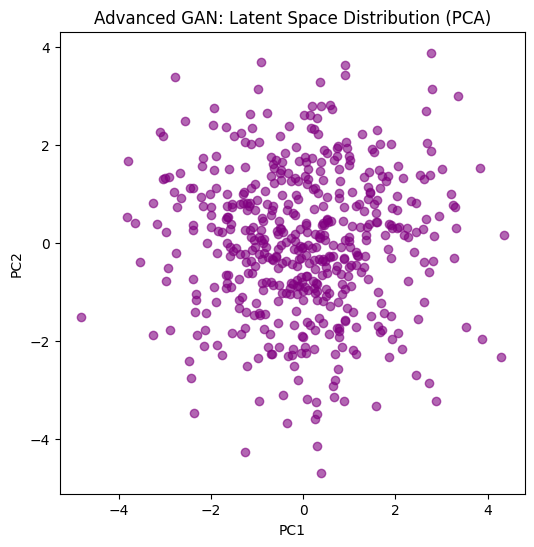

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Lab completely packaged and ready!


In [8]:
# --- CELL 4: GENERATION, PCA VISUALIZATION, AND ZIP ---
import os

# 1. Generate Samples
print("\nGenerating final samples...")
noise = torch.randn(10, latent_dim).to(device)
with torch.no_grad():
    gen_imgs = generator(noise).cpu()
vutils.save_image((gen_imgs + 1)/2, output_dir / "advanced_samples.png", nrow=5)

# 2. Latent Interpolation
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)
interp_imgs = []
for alpha in torch.linspace(0, 1, 10):
    z = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        interp_imgs.append(generator(z).cpu())
vutils.save_image((torch.cat(interp_imgs) + 1)/2, output_dir / "advanced_interp.png", nrow=10)

# 3. PCA Visualization
print("Visualizing Latent Space via PCA...")
latent_vectors = torch.randn(500, latent_dim)
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors.numpy())

plt.figure(figsize=(6,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], alpha=0.6, color='purple')
plt.title("Advanced GAN: Latent Space Distribution (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig(output_dir / "pca_visualization.png")
plt.show()

# 4. Create README and Zip
readme = f"""CSET419 - Generative AI Lab 8
Student: Gaurav
Architecture: Advanced GAN (mini-StyleGAN with Mapping Network)
Latent Dim: {latent_dim} | Image Size: {image_size}x{image_size}
Epochs: {epochs}
"""
with open(output_dir / "README.txt", "w") as f:
    f.write(readme)

zip_path = Path("Lab8_Advanced_Submission.zip")
os.system(f"zip -r {zip_path} {output_dir}")

try:
    from google.colab import files
    files.download(str(zip_path))
except:
    pass
print("\nLab completely packaged and ready!")